In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model = 'text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='imcome_tex_collection',
    persist_directory='./chroma'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [4]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [6]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    query = state['query']
    context = state['context']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

In [7]:
from typing import Literal

doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    query = state['query']
    context = state['context']
    print(f'context == {context}')

    doc_relevance_rag_chain = doc_relevance_prompt | llm
    response = doc_relevance_rag_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response == {response}')

    if response['Score'] == 1:
        return 'relevant'
    return 'irrelevant'

In [8]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

rewrite_prompt = PromptTemplate.from_template("""
사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요.
질문: {query}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})
    print(f"rewrite response: {response}")

    return {'query': response}

## [Tavily](https://www.tavily.com/)

- 웹 검색 시 LangChain에서 많이 사용

### [Tavily search integration](https://docs.langchain.com/oss/python/integrations/tools/tavily_search)

In [9]:
%pip install -q langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [10]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
)

def web_search(state: AgentState):
    query = state["query"]
    response = tavily_search_tool.invoke({'query': query})
    print(f"web search response: {response}")
    return {'context': response}

In [11]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [12]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'rewrite'
    }
)
graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [13]:
graph = graph_builder.compile()

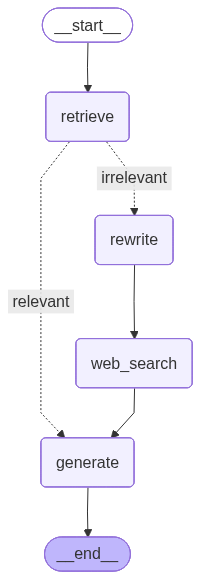

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
query = "연봉 5천만원인 거주자의 소득세는 얼마인가요?"

initial_state = {'query': query}
graph.invoke(initial_state)

context == [Document(id='289e9e4a-2425-4ae1-a933-98d388b6780e', metadata={'source': './documents/income_tax.txt'}, page_content='| 총급여액                      | 공제액                                             |\n|-------------------------------|---------------------------------------------------|\n| 500만원 이하                     | 총 급여액의 100분의 70                               |\n| 500만원 초과 1천 500만원 이하 | 350만원+(500만원을 초과하는 금액의 100분의 40)        |\n| 1천 500만원 초과 3천 500만원 이하 | 750만원+(1천 500만원을 초과하는 경우의 100분의 15)   |\n| 3천 500만원 초과 1억원 이하       | 1천 200만원+(3천 500만원을 초과하는 금액의 100분의 5)|\n| 1억원 초과                      | 1천 475만원+(1억원을 초과하는 금액의 100분의 2)       |\n② 일용근로자에 대한 공제액은 제1항에도 불구하고 1일 15만원으로 한다.<개정 2018. 12. 31.>\n③ 근로소득이 있는 거주자의 해당 과세기간의 총급여액이 제1항 또는 제2항의 공제액에 미달하는 경우에는 그 총급여액을 공제액으로 한다.\n④ 제1항부터 제3항까지의 규정에 따른 공제를 “근로소득공제”라 한다.\n⑤ 제1항의 경우에 2인 이상으로부터 근로소득을 받는 사람(일용근로자는 제외한다)에 대하여는 그 근로소득의 합계액을 총급여액으로 하여 제1항에 따라 계산한 근로소득공제액을 총급여액에서 공제한다.<개정 2010. 12. 27.>\n⑥ 삭제<2010. 12. 27.>\n[전문개정 2009. 1

{'query': '연봉 5천만원인 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='289e9e4a-2425-4ae1-a933-98d388b6780e', metadata={'source': './documents/income_tax.txt'}, page_content='| 총급여액                      | 공제액                                             |\n|-------------------------------|---------------------------------------------------|\n| 500만원 이하                     | 총 급여액의 100분의 70                               |\n| 500만원 초과 1천 500만원 이하 | 350만원+(500만원을 초과하는 금액의 100분의 40)        |\n| 1천 500만원 초과 3천 500만원 이하 | 750만원+(1천 500만원을 초과하는 경우의 100분의 15)   |\n| 3천 500만원 초과 1억원 이하       | 1천 200만원+(3천 500만원을 초과하는 금액의 100분의 5)|\n| 1억원 초과                      | 1천 475만원+(1억원을 초과하는 금액의 100분의 2)       |\n② 일용근로자에 대한 공제액은 제1항에도 불구하고 1일 15만원으로 한다.<개정 2018. 12. 31.>\n③ 근로소득이 있는 거주자의 해당 과세기간의 총급여액이 제1항 또는 제2항의 공제액에 미달하는 경우에는 그 총급여액을 공제액으로 한다.\n④ 제1항부터 제3항까지의 규정에 따른 공제를 “근로소득공제”라 한다.\n⑤ 제1항의 경우에 2인 이상으로부터 근로소득을 받는 사람(일용근로자는 제외한다)에 대하여는 그 근로소득의 합계액을 총급여액으로 하여 제1항에 따라 계산한 근로소득공제액을 총급여액에서 공제한다.<개정 2010. 12. 

In [17]:
temp_state = {'query': '강남역 맛집은?'}
graph.invoke(temp_state)

context == [Document(id='44429947-0c83-4f58-aacc-e889b418153e', metadata={'source': './documents/income_tax.txt'}, page_content='법제처 93 국가법령정보센터\n소득세법\n가. 내국법인이 발행한 주식 또는 출자지분과 그 밖의 유가증권\n나. 외국법인이 발행한 주식 또는 출자지분(중교시장에 상장된 것만 해당한다)\n다. 외국법인의 국내사업장이 발행한 그 밖의 유가증권\n국내원천 기타소득: 제12호부터 제8호까지, 제8호2, 제9호부터 제11호까지의 규정에 따른 소득 외의 소득으로\n서 다음 각 목의 어느 하나에 해당하는 소득\n가. 국내에 있는 부동산 및 그 밖의 자산 또는 국내에서 경영하는 사업과 관련하여 받은 보험금, 보상금 또는 손해배상금\n나. 국내에서 지급하는 위약금 또는 배상금으로서 대통령령으로 정하는 소득\n다. 국내에서 지급하는 상금, 현상금, 포상금이나 그 밖에 이에 준하는 소득, 다만, 제12조제5호다목에서 규정하는 상금·부상은 제외한다.\n라. 국내에서 발결된 매장물로 인한 소득\n마. 국내법에 따른 절차·허가 또는 그 밖의 이와 유사한 처분에 따라 설정된 권리와 그 밖의 부동산 외의 국내자산을 양도함으로써 생기는 소득\n바. 국내에서 발행된 복권, 경품권 또는 그 밖의 추천권에 당첨되어 받는 당첨금과 승마투표권, 승자투표권, 소싸움경기의투표권, 체육진흥투표권의 구매자가 받는 환급금\n사. 슬롯머신등을 이용하는 행위에 참가하여 받는 당첨금품 등\n아. 탕여시법, 제67조에 따라 기타소득으로 처분된 금액\n자. 대통령령으로 정하는 특수관계에 있는 비거주자(이하 제156조에서 “국외특수관계인”이라 한다)가 보유하고 있는 내국법인의 주식 또는 출자지분이 대통령령으로 정하는 자본거래로 인하여 그 가치가 증가함으로써 발생하는 소득\n차. 국내의 임금계좌에서 연금이수령하는 금액으로서 제12조제11항제12호의 소득\n카. 사용지 기준 조세조약 상대국의 거주

{'query': '강남역 주변에 인기 있는 맛집 추천 바랍니다.',
 'context': {'query': '강남역 주변에 인기 있는 맛집 추천 바랍니다.',
  'follow_up_questions': None,
  'answer': None,
  'images': [],
  'results': [{'url': 'https://hotel-iu.tistory.com/7776',
    'title': '강남역 근처 맛집 베스트 추천 top 10',
    'content': '1: 봉우화로. 상호명: 봉우화로 · 2: 마초쉐프 강남본점. 상호명: 마초쉐프 강남본점 · 3: 쭈꾸미랩소디 강남점. 상호명: 쭈꾸미랩소디 강남점 · 4: 을지다락',
    'score': 0.87681407,
    'raw_content': None},
   {'url': 'https://blog.naver.com/gywniloveyou/223660588182',
    'title': '강남역 맛집 추천! 놓치면 아쉬운 핫플레이스 5곳 모음 : 네이버 블로그',
    'content': '1. 딸부자네 불백 · 위치: 강남구 봉은사로6길 38 정암빌딩 · 추천 메뉴: 딸불백정식, 소불백정식 · 푸짐한 제육볶음과 공기밥, 쌈채소가 기본으로 제공되는',
    'score': 0.86767644,
    'raw_content': None},
   {'url': 'http://m.menupan.com/board/qna_view.asp?bt=r&id=13525',
    'title': 'A. - re)강남역 근처 맛집~ - 2007-11-09 - 야옹박사 - 추천',
    'content': '꼬메쁘리마와 프레스코를 추천드립니다. 둘 다 가격은 다른 음식점들에 비해 아주 좋아요. 꼬메쁘리마는 메뉴판 프리미엄 할인이나 예약쿠폰을 받으면',
    'score': 0.8565368,
    'raw_content': None}],
  'response_time': 0.71,
  '

## rewrite

사용자 질문: 강남역 맛집은?
웹 검색을 위한 사용자 질문 수정: `강남역 주변에 인기 있는 맛집 추천 바랍니다.`

> `주변 인기`와 `추천 바랍니다`와 같이 공손한 표현만 추가됨